In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.constants import physical_constants as physical_constants
c = physical_constants['speed of light in vacuum'][0]

In [26]:
directory = '/Users/bruno/Library/Mobile Documents/com~apple~CloudDocs/Thesis/Jupter Notebooks/190425_coupler_S13/S13_Al/'

In [29]:
# Split CSV file 
rows_per_file = 10
csvfile = open(directory + 'S13_Al.csv', 'r').readlines()
filename = '0'
counter = 0
for i in range(len(csvfile)):
    if i % rows_per_file == 0:
        open(str(directory + filename) + '.csv', 'w+').writelines(csvfile[i:i+rows_per_file])
        counter += 1
        filename = str(counter)

In [205]:
# Read CSV files into dictionary
data = {}
for i in range(1,35):
    df = pd.read_csv(directory + str(i) + '.csv')
    header = df.columns[0]
    Lcoupler = header[header.index('Lcoupler='):][9:][:-2]
    data[Lcoupler] = {}
    for j in range(1,len(df[header].index)):
        Freq = df[header].index[j]
        S13 = df[header][j]
        data[Lcoupler][Freq] = S13

In [372]:
# Structure data on frequency basis
n = 1

data2 = {}
for i in range(2,9):
    data2[str(i)] = {}
    data2[str(i)]['Lcoupler'] = np.array([])
    data2[str(i)]['S13'] = np.array([])
    data2[str(i)]['Q_C'] = np.array([])
for Lcoupler, table in data.items():
    for Freq, S13 in table.items():
        data2[Freq]['Lcoupler'] = np.append(data2[Freq]['Lcoupler'], np.array([float(Lcoupler)]))
        data2[Freq]['S13'] = np.append(data2[Freq]['S13'], np.array([float(S13)]))
for i in range(2,9):
    argsort = np.argsort(data2[str(i)]['Lcoupler'])
    data2[str(i)]['Lcoupler'] = data2[str(i)]['Lcoupler'][argsort]
    data2[str(i)]['S13'] = data2[str(i)]['S13'][argsort]

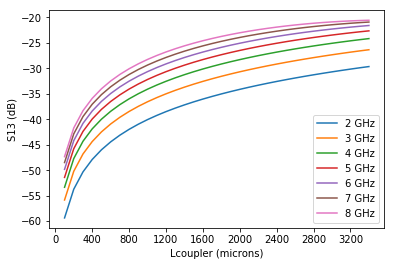

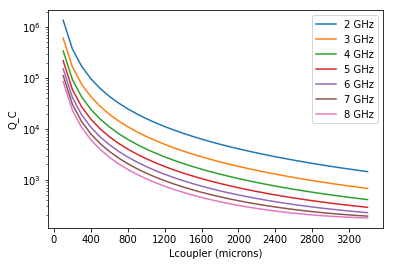

In [393]:
# Plot results
fig1 = plt.figure()
ax1 = plt.axes()
for i in range(2,9):
    ax1.plot(data2[str(i)]['Lcoupler'], data2[str(i)]['S13'], label = str(i) + ' GHz')
    ax1.xaxis.set_major_locator(plt.MaxNLocator(10))
ax1.legend()
ax1.set(xlabel='Lcoupler (microns)', ylabel='S13 (dB)')

n = 1

fig2 = plt.figure()
ax2 = plt.axes()
for i in range(2,9):
    S13_squared = np.power(10, data2[str(i)]['S13']/10)
    ax2.plot(data2[str(i)]['Lcoupler'], n*np.pi/(2*S13_squared), label = str(i) + ' GHz')
    ax2.xaxis.set_major_locator(plt.MaxNLocator(10))
ax2.legend()
ax2.set(xlabel='Lcoupler (microns)', ylabel='Q_C')
ax2.set_yscale('log')